/tmp/ipython-input-263/2342884434.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


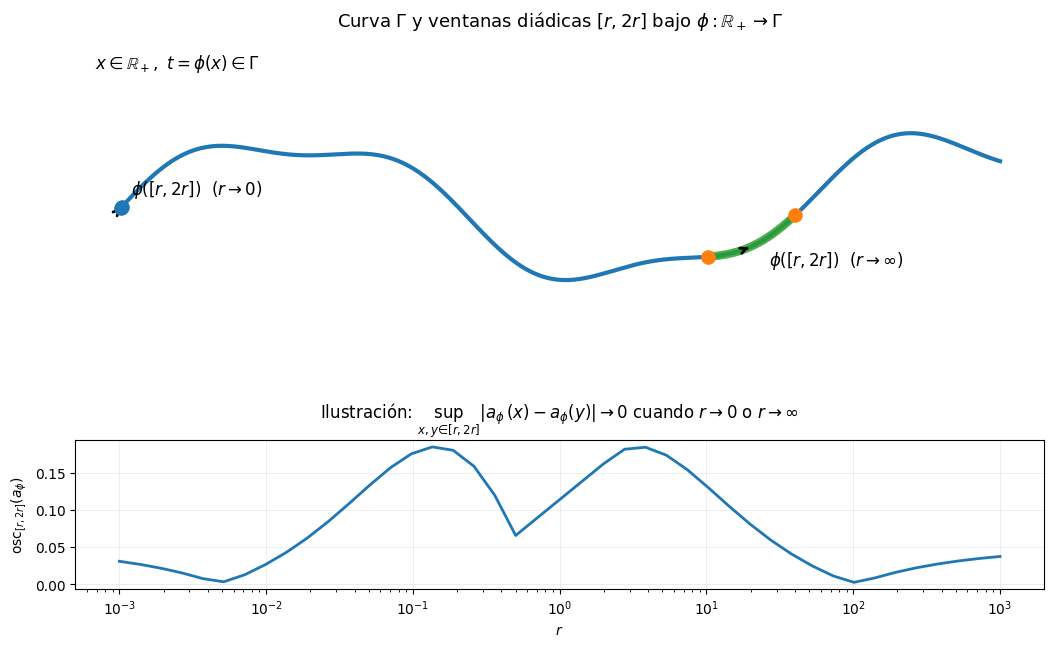

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# -----------------------------
# Parametrización φ: R+ -> Γ
# Usaremos x>0 y definimos una curva suave Γ en el plano.
# -----------------------------
def phi(x):
    """
    Parametrización de una curva Γ en C.
    Queremos que cuando x->0 y x->∞, el punto recorra extremos distintos.
    """
    # Escala y forma (suave, con ondulación)
    # u = log(1+x) ayuda a extender bien para x grande
    u = np.log1p(x)
    X = u
    Y = 0.55*np.sin(1.2*u) + 0.12*np.sin(3.4*u)
    return X + 1j*Y

# -----------------------------
# a_phi(x) "slowly oscillating" (ejemplo ilustrativo)
# Oscila, pero su oscilación en ventanas [r,2r] tiende a 0
# cuando r->0 o r->∞.
# -----------------------------
def a_phi(x):
    # Usamos una oscilación con frecuencia que se "aplana" en escala diádica:
    # sin(log log(e + 1/x)) para x->0 y sin(log log(e + x)) para x->∞.
    # Lo combinamos suavemente.
    x = np.asarray(x)
    small = np.sin(np.log(np.log(np.e + 1.0/(x + 1e-12))))
    large = np.sin(np.log(np.log(np.e + x)))
    # Mezcla suave
    w = 1.0/(1.0 + x)
    return w*small + (1-w)*large

def osc_on_window(r):
    xs = np.linspace(r, 2*r, 400)
    vals = a_phi(xs)
    return float(np.max(vals) - np.min(vals))

def arrow(ax, z1, z2, lw=2):
    ax.annotate(
        "",
        xy=(z2.real, z2.imag),
        xytext=(z1.real, z1.imag),
        arrowprops=dict(arrowstyle="->", lw=lw),
    )

def main():
    fig = plt.figure(figsize=(12.5, 7.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.3], hspace=0.25)

    ax = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])

    # Fondo tipo "slide"
    ax.grid(True, linewidth=0.6, alpha=0.25)
    ax2.grid(True, linewidth=0.6, alpha=0.25)

    # Curva Γ
    x_all = np.logspace(-3, 3, 3000)  # x en (0,∞) aproximado
    z_all = phi(x_all)
    ax.plot(z_all.real, z_all.imag, lw=3)

    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(r"Curva $\Gamma$ y ventanas diádicas $[r,2r]$ bajo $\phi:\mathbb{R}_+\to\Gamma$",
                 fontsize=13)

    # Elegimos dos ventanas: una con r pequeño, otra con r grande
    r_small = 1e-2
    r_large = 1e2

    for r, label, dy in [(r_small, r"$r\to 0$", 0.10), (r_large, r"$r\to\infty$", -0.18)]:
        xs = np.linspace(r, 2*r, 300)
        zs = phi(xs)

        # Resaltar el arco φ([r,2r]) en Γ
        ax.plot(zs.real, zs.imag, lw=6, alpha=0.85)

        # Marcar extremos de la ventana en Γ
        zA = zs[0]
        zB = zs[-1]
        ax.scatter([zA.real, zB.real], [zA.imag, zB.imag], s=90, zorder=5)

        # Flecha de orientación sobre el arco
        arrow(ax, zs[len(zs)//3], zs[len(zs)//3 + 15], lw=2)

        # Etiqueta [r,2r] cerca del arco
        zm = zs[len(zs)//2]
        ax.text(zm.real + 0.08, zm.imag + dy, rf"$\phi([r,2r])$  ({label})",
                fontsize=12)

    # Etiquetas globales
    ax.text(0.02, 0.95, r"$x\in\mathbb{R}_+,\ t=\phi(x)\in\Gamma$",
            transform=ax.transAxes, fontsize=12, va="top")

    # Panel inferior: oscilación en ventanas
    rs1 = np.logspace(-3, -0.3, 20)     # r -> 0
    rs2 = np.logspace(0.3, 3, 20)       # r -> ∞
    rs = np.concatenate([rs1, rs2])
    oscs = np.array([osc_on_window(r) for r in rs])

    ax2.plot(rs, oscs, lw=2)
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\mathrm{osc}_{[r,2r]}(a_\phi)$")
    ax2.set_title(r"Ilustración: $\sup_{x,y\in[r,2r]}|a_\phi(x)-a_\phi(y)|\to 0$ cuando $r\to 0$ o $r\to\infty$",
                  fontsize=12)

    # Limpieza estilo slide
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

/tmp/ipython-input-263/4028504110.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


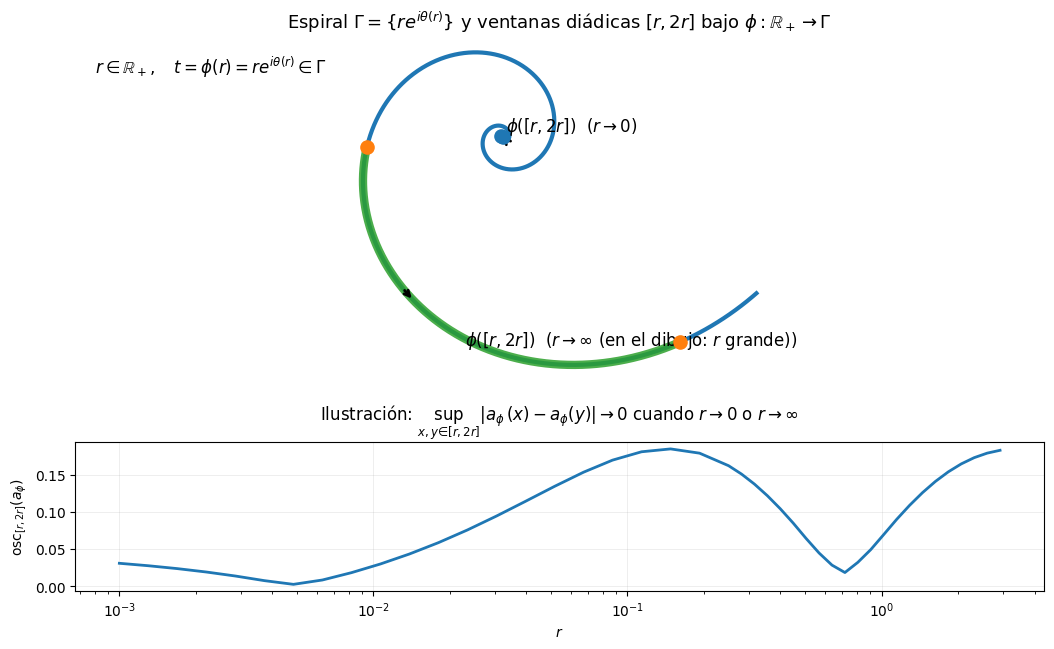

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Curva Γ como espiral:  Γ = { r e^{i θ(r)} : r>0 }
# ============================================================

def theta_of_r(r, k=3.2, theta0=0.0):
    """
    Ángulo de la espiral. Elegimos θ(r)=θ0 + k log r (espiral logarítmica).
    - r -> 0  => log r -> -∞  => muchas vueltas cerca del origen
    - r -> ∞  => log r -> ∞   => vueltas hacia afuera
    """
    r = np.asarray(r)
    return theta0 + k * np.log(r)

def phi(r):
    """
    Parametrización φ: R+ -> Γ,  r ↦ r e^{i θ(r)}.
    Devuelve un complejo t=φ(r)∈Γ.
    """
    th = theta_of_r(r)
    return r * np.exp(1j * th)

# ============================================================
# 2) Ejemplo a_φ(r) "slowly oscillating" en R+
#    (oscilación en ventanas [r,2r] tiende a 0 cuando r->0 y r->∞)
# ============================================================

def a_phi(r):
    """
    Ejemplo ilustrativo: oscila infinitamente, pero 'se aplana' en ventanas diádicas
    cerca de 0 y de ∞.

    Nota: Esto es un ejemplo para visualización, no un "teorema" de clase.
    """
    r = np.asarray(r)
    small = np.sin(np.log(np.log(np.e + 1.0/(r + 1e-12))))
    large = np.sin(np.log(np.log(np.e + r)))
    w = 1.0 / (1.0 + r)  # mezcla suave: cerca de 0 domina small, cerca de ∞ domina large
    return w * small + (1.0 - w) * large

def osc_on_window(r0):
    rr = np.linspace(r0, 2*r0, 500)
    vals = a_phi(rr)
    return float(np.max(vals) - np.min(vals))

def add_arrow(ax, z1, z2, lw=2):
    ax.annotate(
        "",
        xy=(z2.real, z2.imag),
        xytext=(z1.real, z1.imag),
        arrowprops=dict(arrowstyle="->", lw=lw),
    )

# ============================================================
# 3) Dibujo principal: Γ + arcos φ([r,2r]) para r pequeño y r grande
# ============================================================

def main():
    fig = plt.figure(figsize=(12.5, 7.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.3], hspace=0.25)

    ax = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])

    # Fondo tipo slide (cuadrícula suave)
    ax.grid(True, linewidth=0.6, alpha=0.25)
    ax2.grid(True, linewidth=0.6, alpha=0.25)

    # Rango FINITO de r para dibujar (evita valores enormes)
    r_min = 1e-3
    r_max = 6.0
    r_all = np.logspace(np.log10(r_min), np.log10(r_max), 3500)

    z_all = phi(r_all)
    ax.plot(z_all.real, z_all.imag, lw=3)

    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(
        r"Espiral $\Gamma=\{r e^{i\theta(r)}\}$ y ventanas diádicas $[r,2r]$ bajo $\phi:\mathbb{R}_+\to\Gamma$",
        fontsize=13
    )

    # Ventanas: una cerca de 0, otra "hacia ∞" (en nuestro rango, cerca de r_max)
    r_small = 2e-2
    r_large = r_max / 2.2  # para que [r,2r] quede dentro de [r_min,r_max]

    for r0, label, dy in [
        (r_small, r"$r\to 0$", 0.10),
        (r_large, r"$r\to\infty$ (en el dibujo: $r$ grande)", -0.18),
    ]:
        rr = np.linspace(r0, 2*r0, 500)
        zz = phi(rr)

        # Resaltar el arco φ([r,2r])
        ax.plot(zz.real, zz.imag, lw=6, alpha=0.85)

        # Extremos del arco
        zA, zB = zz[0], zz[-1]
        ax.scatter([zA.real, zB.real], [zA.imag, zB.imag], s=90, zorder=5)

        # Flecha de orientación sobre el arco
        j = len(zz) // 3
        add_arrow(ax, zz[j], zz[j + 18], lw=2)

        # Etiqueta
        zm = zz[len(zz) // 2]
        ax.text(
            zm.real + 0.08, zm.imag + dy,
            rf"$\phi([r,2r])$  ({label})",
            fontsize=12
        )

    # Etiquetas globales
    ax.text(
        0.02, 0.95,
        r"$r\in\mathbb{R}_+,\quad t=\phi(r)=r e^{i\theta(r)}\in\Gamma$",
        transform=ax.transAxes, fontsize=12, va="top"
    )

    # ============================================================
    # Panel inferior: oscilación en ventanas [r,2r]
    # (en nuestro rango finito, mostramos tendencia al ir a r_min y a r_max)
    # ============================================================
    rs1 = np.logspace(np.log10(r_min), np.log10(0.25), 22)          # hacia 0
    rs2 = np.logspace(np.log10(0.25), np.log10(r_max/2.05), 22)    # hacia grande
    rs = np.unique(np.concatenate([rs1, rs2]))
    oscs = np.array([osc_on_window(r0) for r0 in rs])

    ax2.plot(rs, oscs, lw=2)
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\mathrm{osc}_{[r,2r]}(a_\phi)$")
    ax2.set_title(
        r"Ilustración: $\sup_{x,y\in[r,2r]}|a_\phi(x)-a_\phi(y)|\to 0$ cuando $r\to 0$ o $r\to\infty$",
        fontsize=12
    )

    # Limpieza estilo slide
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

/tmp/ipython-input-263/3083963887.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


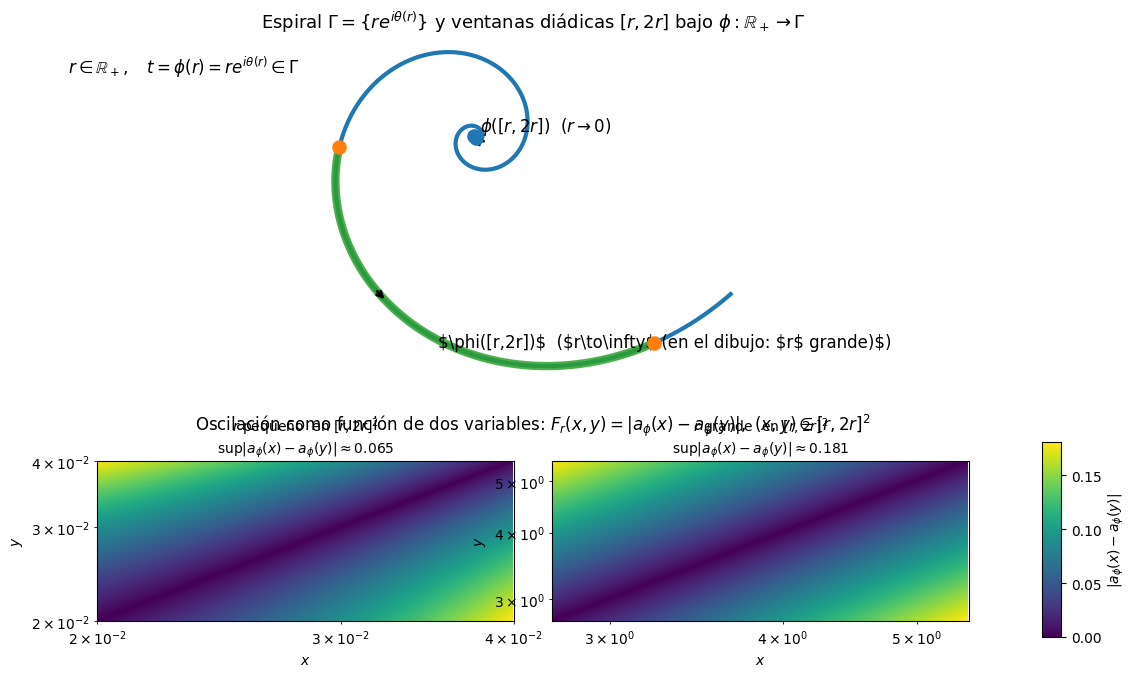

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Curva Γ como espiral:  Γ = { r e^{i θ(r)} : r>0 }
# ============================================================

def theta_of_r(r, k=3.2, theta0=0.0):
    """
    Ángulo de la espiral. Elegimos θ(r)=θ0 + k log r (espiral logarítmica).
    - r -> 0  => log r -> -∞  => muchas vueltas cerca del origen
    - r -> ∞  => log r -> ∞   => vueltas hacia afuera
    """
    r = np.asarray(r)
    return theta0 + k * np.log(r)

def phi(r):
    """
    Parametrización φ: R+ -> Γ,  r ↦ r e^{i θ(r)}.
    Devuelve un complejo t=φ(r)∈Γ.
    """
    th = theta_of_r(r)
    return r * np.exp(1j * th)

# ============================================================
# 2) Ejemplo a_φ(r) "slowly oscillating" en R+
# ============================================================

def a_phi(r):
    """
    Ejemplo ilustrativo: oscila infinitamente, pero 'se aplana' en ventanas [r,2r]
    cerca de 0 y de ∞.
    """
    r = np.asarray(r)
    small = np.sin(np.log(np.log(np.e + 1.0/(r + 1e-12))))
    large = np.sin(np.log(np.log(np.e + r)))
    w = 1.0 / (1.0 + r)  # mezcla suave: cerca de 0 domina small, cerca de ∞ domina large
    return w * small + (1.0 - w) * large

def add_arrow(ax, z1, z2, lw=2):
    ax.annotate(
        "",
        xy=(z2.real, z2.imag),
        xytext=(z1.real, z1.imag),
        arrowprops=dict(arrowstyle="->", lw=lw),
    )

# ============================================================
# 3) Panel inferior: oscilación como función de DOS variables x,y
#    Definimos F_r(x,y) = |a_phi(x) - a_phi(y)|,  x,y in [r,2r].
#    Mostramos un "mapa" en el cuadrado [r,2r]×[r,2r] para r pequeño y r grande.
# ============================================================

def diff_grid_on_window(r0, n=180):
    """
    Devuelve malla X,Y en [r0,2r0] y F(X,Y)=|a_phi(X)-a_phi(Y)|.
    """
    xs = np.linspace(r0, 2*r0, n)
    ys = np.linspace(r0, 2*r0, n)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    F = np.abs(a_phi(X) - a_phi(Y))
    return xs, ys, F

def sup_on_window(r0, n=300):
    """
    Aproxima sup_{x,y in [r,2r]} |a_phi(x)-a_phi(y)|.
    """
    xs = np.linspace(r0, 2*r0, n)
    vals = a_phi(xs)
    return float(np.max(vals) - np.min(vals))  # equivalente al sup de la diferencia

def main():
    fig = plt.figure(figsize=(12.5, 7.8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.7], hspace=0.22)

    ax = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])

    # Fondo tipo slide (cuadrícula suave)
    ax.grid(True, linewidth=0.6, alpha=0.25)
    ax2.grid(True, linewidth=0.6, alpha=0.25)

    # -----------------------------
    # Curva Γ (espiral)
    # -----------------------------
    r_min = 1e-3
    r_max = 6.0
    r_all = np.logspace(np.log10(r_min), np.log10(r_max), 3500)

    z_all = phi(r_all)
    ax.plot(z_all.real, z_all.imag, lw=3)

    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(
        r"Espiral $\Gamma=\{r e^{i\theta(r)}\}$ y ventanas diádicas $[r,2r]$ bajo $\phi:\mathbb{R}_+\to\Gamma$",
        fontsize=13
    )

    # Ventanas: una cerca de 0, otra "hacia ∞" (en el dibujo: r grande)
    r_small = 2e-2
    r_large = r_max / 2.2  # para que [r,2r] quede dentro de [r_min,r_max]

    for r0, label, dy in [
        (r_small, r"$r\to 0$", 0.10),
        (r_large, r"$r\to\infty$ (en el dibujo: $r$ grande)$", -0.18),
    ]:
        rr = np.linspace(r0, 2*r0, 500)
        zz = phi(rr)

        # Resaltar el arco φ([r,2r])
        ax.plot(zz.real, zz.imag, lw=6, alpha=0.85)

        # Extremos del arco
        zA, zB = zz[0], zz[-1]
        ax.scatter([zA.real, zB.real], [zA.imag, zB.imag], s=90, zorder=5)

        # Flecha de orientación sobre el arco
        j = len(zz) // 3
        add_arrow(ax, zz[j], zz[j + 18], lw=2)

        # Etiqueta
        zm = zz[len(zz) // 2]
        ax.text(
            zm.real + 0.08, zm.imag + dy,
            rf"$\phi([r,2r])$  ({label})",
            fontsize=12
        )

    ax.text(
        0.02, 0.95,
        r"$r\in\mathbb{R}_+,\quad t=\phi(r)=r e^{i\theta(r)}\in\Gamma$",
        transform=ax.transAxes, fontsize=12, va="top"
    )

    # -----------------------------
    # Panel inferior: mostrar dependencia en (x,y)
    # Usamos 2 mapas: uno para r_small y otro para r_large
    # -----------------------------
    ax2.set_axis_off()
    ax2.set_title(
        r"Oscilación como función de dos variables: $F_r(x,y)=|a_\phi(x)-a_\phi(y)|,\ (x,y)\in[r,2r]^2$",
        fontsize=12, pad=8
    )

    # Creamos dos "insets" dentro del panel inferior
    left = ax2.inset_axes([0.05, 0.08, 0.43, 0.82])
    right = ax2.inset_axes([0.52, 0.08, 0.43, 0.82])

    for axh, r0, lab in [
        (left, r_small, r"$r$ pequeño"),
        (right, r_large, r"$r$ grande"),
    ]:
        xs, ys, F = diff_grid_on_window(r0, n=180)
        im = axh.imshow(
            F,
            origin="lower",
            extent=[xs[0], xs[-1], ys[0], ys[-1]],
            aspect="auto",
        )
        axh.set_xscale("log")
        axh.set_yscale("log")
        axh.grid(True, linewidth=0.5, alpha=0.20)
        axh.set_xlabel(r"$x$")
        axh.set_ylabel(r"$y$")
        axh.set_title(
            rf"{lab}  en $[r,2r]^2$" "\n"
            rf"$\sup |a_\phi(x)-a_\phi(y)| \approx {sup_on_window(r0):.3f}$",
            fontsize=10
        )

    # Una sola barra de color para ambos mapas
    cax = fig.add_axes([0.92, 0.11, 0.015, 0.25])
    fig.colorbar(im, cax=cax, label=r"$|a_\phi(x)-a_\phi(y)|$")

    # Limpieza estilo slide arriba
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    plt.tight_layout(rect=[0, 0, 0.90, 1.0])
    plt.show()

if __name__ == "__main__":
    main()

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ============================
# Espiral logarítmica: t = r e^{i k log r}
# ============================
def phi(r, k=3.2, theta0=0.0):
    r = np.asarray(r)
    theta = theta0 + k * np.log(r)
    return r * np.exp(1j * theta)

def fig_to_rgb_array(fig):
    """
    Convierte un Figure de Matplotlib a arreglo RGB uint8 de forma robusta
    (usa buffer_rgba, compatible con FigureCanvasAgg moderno).
    """
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())  # shape (H,W,4), uint8
    rgb = rgba[..., :3].copy()
    return rgb

def render_frame(fig, ax, z_all, z_seg, title):
    ax.clear()
    ax.grid(True, linewidth=0.6, alpha=0.25)

    # Espiral completa (tenue)
    ax.plot(z_all.real, z_all.imag, lw=2.5, alpha=0.25)

    # Segmento resaltado: φ([r,2r])
    ax.plot(z_seg.real, z_seg.imag, lw=6, alpha=0.95)

    # Extremos del segmento
    ax.scatter([z_seg[0].real, z_seg[-1].real],
               [z_seg[0].imag, z_seg[-1].imag], s=80)

    # Estética tipo slide
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    return fig_to_rgb_array(fig)

def make_gif(
    out_path: str,
    r_path: np.ndarray,
    rmin_all: float,
    rmax_all: float,
    k: float = 3.2,
    fps: int = 18,
    n_all: int = 5000,
    n_seg: int = 600,
    figsize=(8.8, 6.2),
    title_prefix="",
):
    # Espiral "global" en un rango fijo para todo el gif
    r_all = np.logspace(np.log10(rmin_all), np.log10(rmax_all), n_all)
    z_all = phi(r_all, k=k)

    fig, ax = plt.subplots(figsize=figsize)

    frames = []
    for r0 in r_path:
        rr = np.linspace(r0, 2*r0, n_seg)
        # recorte de seguridad al rango global
        rr = rr[(rr >= rmin_all) & (rr <= rmax_all)]
        if len(rr) < 5:
            continue

        z_seg = phi(rr, k=k)
        title = title_prefix + rf"  ventana $[r,2r]$ con $r={r0:.2g}$"
        frames.append(render_frame(fig, ax, z_all, z_seg, title))

    plt.close(fig)
    imageio.mimsave(out_path, frames, fps=fps)
    print(f"[OK] GIF guardado en: {out_path}")

def main():
    # ============================
    # GIF 1: r -> 0 (ventanas cada vez más pequeñas)
    # ============================
    rmin_all_1 = 1e-4
    rmax_all_1 = 3.0

    n_frames_1 = 80
    r_start_1 = 0.9
    r_end_1 = 1.2e-3
    r_path_1 = np.geomspace(r_start_1, r_end_1, n_frames_1)

    make_gif(
        out_path="spiral_window_to_zero.gif",
        r_path=r_path_1,
        rmin_all=rmin_all_1,
        rmax_all=rmax_all_1,
        k=3.2,
        fps=18,
        title_prefix=r"Espiral logarítmica: $r\to 0$",
    )

    # ============================
    # GIF 2: r -> "infty" (ventanas cada vez más grandes)
    # En la práctica: r crece hasta rmax_all_2.
    # ============================
    rmin_all_2 = 1e-3
    rmax_all_2 = 80.0

    n_frames_2 = 80
    r_start_2 = 0.08
    r_end_2 = 35.0
    r_path_2 = np.geomspace(r_start_2, r_end_2, n_frames_2)

    make_gif(
        out_path="spiral_window_to_infty.gif",
        r_path=r_path_2,
        rmin_all=rmin_all_2,
        rmax_all=rmax_all_2,
        k=3.2,
        fps=18,
        title_prefix=r"Espiral logarítmica: $r\to\infty$ (rango finito)",
    )

if __name__ == "__main__":
    main()

[OK] GIF guardado en: spiral_window_to_zero.gif
[OK] GIF guardado en: spiral_window_to_infty.gif


In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

def phi(r, k=3.2, theta0=0.0):
    r = np.asarray(r)
    theta = theta0 + k * np.log(r)
    return r * np.exp(1j * theta)

def fig_to_rgb_array(fig):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())  # (H,W,4) uint8
    return rgba[..., :3].copy()

def render_frame(fig, ax, z_all, z_seg, title):
    ax.clear()
    ax.grid(True, linewidth=0.6, alpha=0.25)

    ax.plot(z_all.real, z_all.imag, lw=2.5, alpha=0.25)
    ax.plot(z_seg.real, z_seg.imag, lw=6, alpha=0.95)
    ax.scatter([z_seg[0].real, z_seg[-1].real],
               [z_seg[0].imag, z_seg[-1].imag], s=80)

    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

    return fig_to_rgb_array(fig)

def make_gif(out_path, r_path, rmin_all, rmax_all, k=3.2, fps=18,
             n_all=5000, n_seg=600, figsize=(8.8, 6.2), title_prefix=""):
    r_all = np.logspace(np.log10(rmin_all), np.log10(rmax_all), n_all)
    z_all = phi(r_all, k=k)

    fig, ax = plt.subplots(figsize=figsize)

    frames = []
    for r0 in r_path:
        rr = np.linspace(r0, 2*r0, n_seg)
        rr = rr[(rr >= rmin_all) & (rr <= rmax_all)]
        if len(rr) < 5:
            continue
        z_seg = phi(rr, k=k)
        title = title_prefix + rf"  ventana $[r,2r]$ con $r={r0:.2g}$"
        frames.append(render_frame(fig, ax, z_all, z_seg, title))

    plt.close(fig)

    # loop=0  => repetir infinitamente
    imageio.mimsave(out_path, frames, fps=fps, loop=0)
    print(f"[OK] GIF guardado en: {out_path} (loop infinito)")

def main():
    # GIF 1: r -> 0
    rmin_all_1 = 1e-4
    rmax_all_1 = 3.0
    r_path_1 = np.geomspace(0.9, 1.2e-3, 80)

    make_gif(
        out_path="spiral_window_to_zero.gif",
        r_path=r_path_1,
        rmin_all=rmin_all_1,
        rmax_all=rmax_all_1,
        k=3.2,
        fps=18,
        title_prefix=r"Espiral logarítmica: $r\to 0$",
    )

    # GIF 2: r -> ∞ (en rango finito)
    rmin_all_2 = 1e-3
    rmax_all_2 = 80.0
    r_path_2 = np.geomspace(0.08, 35.0, 80)

    make_gif(
        out_path="spiral_window_to_infty.gif",
        r_path=r_path_2,
        rmin_all=rmin_all_2,
        rmax_all=rmax_all_2,
        k=3.2,
        fps=18,
        title_prefix=r"Espiral logarítmica: $r\to\infty$ (rango finito)",
    )

if __name__ == "__main__":
    main()

[OK] GIF guardado en: spiral_window_to_zero.gif (loop infinito)
[OK] GIF guardado en: spiral_window_to_infty.gif (loop infinito)


In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ============================
# Γ: espiral logarítmica  t = r e^{i k log r}
# ============================
def phi(r, k=3.2, theta0=0.0):
    r = np.asarray(r)
    theta = theta0 + k * np.log(r)
    return r * np.exp(1j * theta)

# ============================
# a_phi(r): ejemplo slowly oscillating (para visual)
# ============================
def a_phi(r):
    r = np.asarray(r)
    small = np.sin(np.log(np.log(np.e + 1.0/(r + 1e-12))))
    return small  # enfocamos el extremo r->0 para este GIF

def fig_to_rgb(fig):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[..., :3].copy()

def window_stats(r0, n=700):
    xs = np.linspace(r0, 2*r0, n)
    vals = a_phi(xs)
    i_min = int(np.argmin(vals))
    i_max = int(np.argmax(vals))
    vmin = float(vals[i_min])
    vmax = float(vals[i_max])
    return xs, vals, xs[i_min], vmin, xs[i_max], vmax, (vmax - vmin)

def make_gif_to_zero(
    out_path="spiral_with_osc_to_zero.gif",
    fps=18,
    loop=0,
    k=3.2,
):
    # Rango global para la espiral (fijo)
    r_min_all, r_max_all = 1e-4, 3.0
    r_all = np.logspace(np.log10(r_min_all), np.log10(r_max_all), 5000)
    z_all = phi(r_all, k=k)

    # Frames: r decrece hacia 0
    r_path = np.geomspace(0.9, 1.2e-3, 90)

    fig = plt.figure(figsize=(10.5, 7.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.6], hspace=0.28)
    ax_sp = fig.add_subplot(gs[0, 0])
    ax_fn = fig.add_subplot(gs[1, 0])

    frames = []

    for r0 in r_path:
        # --- segmento φ([r,2r]) ---
        rr = np.linspace(r0, 2*r0, 600)
        rr = rr[(rr >= r_min_all) & (rr <= r_max_all)]
        if len(rr) < 5:
            continue
        z_seg = phi(rr, k=k)

        # --- estadística de oscilación en [r,2r] ---
        xs, vals, x_min, vmin, x_max, vmax, Delta = window_stats(r0)

        # =========================
        # Panel 1: espiral + arco resaltado
        # =========================
        ax_sp.clear()
        ax_sp.grid(True, linewidth=0.6, alpha=0.25)

        ax_sp.plot(z_all.real, z_all.imag, lw=2.5, alpha=0.25)
        ax_sp.plot(z_seg.real, z_seg.imag, lw=6, alpha=0.95)

        ax_sp.scatter([z_seg[0].real, z_seg[-1].real],
                      [z_seg[0].imag, z_seg[-1].imag], s=80)

        ax_sp.set_aspect("equal", adjustable="datalim")
        ax_sp.set_xticks([]); ax_sp.set_yticks([])
        for sp in ax_sp.spines.values():
            sp.set_visible(False)

        ax_sp.set_title(
            rf"Espiral logarítmica ($r\to 0$). Ventana $[r,2r]$ con $r={r0:.3g}$",
            fontsize=12
        )

        # =========================
        # Panel 2: a_phi en [r,2r] + max/min + Delta
        # =========================
        ax_fn.clear()
        ax_fn.grid(True, linewidth=0.6, alpha=0.25)

        ax_fn.plot(xs, vals, lw=2.3)
        ax_fn.scatter([x_min, x_max], [vmin, vmax], s=60)

        # línea vertical mostrando Delta
        x_mid = np.sqrt(r0 * 2*r0)  # punto medio geométrico (bonito en log)
        ax_fn.plot([x_mid, x_mid], [vmin, vmax], lw=2.5)

        # etiquetas
        ax_fn.set_xscale("log")
        ax_fn.set_xlabel(r"$x\in[r,2r]$")
        ax_fn.set_ylabel(r"$a_\phi(x)$")

        ax_fn.text(
            0.02, 0.93,
            rf"$\Delta(r)=\max a_\phi - \min a_\phi = {Delta:.3f}$",
            transform=ax_fn.transAxes,
            fontsize=11,
            va="top"
        )
        ax_fn.text(
            0.02, 0.78,
            r"$\Delta(r)=\sup_{x,y\in[r,2r]}|a_\phi(x)-a_\phi(y)|$",
            transform=ax_fn.transAxes,
            fontsize=11,
            va="top"
        )

        for sp in ax_fn.spines.values():
            sp.set_visible(False)

        frames.append(fig_to_rgb(fig))

    plt.close(fig)
    imageio.mimsave(out_path, frames, fps=fps, loop=loop)
    print(f"[OK] {out_path} (loop={'infinito' if loop==0 else loop})")

if __name__ == "__main__":
    make_gif_to_zero()

[OK] spiral_with_osc_to_zero.gif (loop=infinito)


In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ============================
# Γ: espiral logarítmica  t = r e^{i k log r}
# ============================
def phi(r, k=3.2, theta0=0.0):
    r = np.asarray(r)
    theta = theta0 + k * np.log(r)
    return r * np.exp(1j * theta)

# ============================
# a_phi(r): ejemplo slowly oscillating (para visual)
# ============================
def a_phi(r):
    r = np.asarray(r)
    return np.sin(np.log(np.log(np.e + 1.0/(r + 1e-12))))  # enfocamos r->0

def fig_to_rgb(fig):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[..., :3].copy()

def window_stats(r0, n=900):
    xs = np.linspace(r0, 2*r0, n)
    vals = a_phi(xs)
    i_min = int(np.argmin(vals))
    i_max = int(np.argmax(vals))
    vmin = float(vals[i_min])
    vmax = float(vals[i_max])
    return xs, vals, xs[i_min], vmin, xs[i_max], vmax, (vmax - vmin)

def add_clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

def make_gif_to_zero(
    out_path="spiral_with_osc_to_zero_row.gif",
    seconds_per_frame=0.12,   # <-- MÁS grande = más lento (p.ej. 0.20)
    loop=0,
    k=3.2,
    dpi=180,                 # <-- MÁS grande = más resolución
    figsize=(13.8, 5.4),     # <-- layout horizontal
    n_frames=90,
):
    # Convertimos a fps para imageio (fps = 1/seconds_per_frame)
    fps = max(1, int(round(1.0 / seconds_per_frame)))

    # Rango global para la espiral (fijo)
    r_min_all, r_max_all = 1e-4, 3.0
    r_all = np.logspace(np.log10(r_min_all), np.log10(r_max_all), 6000)
    z_all = phi(r_all, k=k)

    # Frames: r decrece hacia 0
    r_path = np.geomspace(0.9, 1.2e-3, n_frames)

    # FIGURA: 1 fila, 2 columnas
    fig, (ax_sp, ax_fn) = plt.subplots(
        1, 2, figsize=figsize, dpi=dpi, gridspec_kw={"wspace": 0.20}
    )

    frames = []

    for r0 in r_path:
        # --- segmento φ([r,2r]) ---
        rr = np.linspace(r0, 2*r0, 800)
        rr = rr[(rr >= r_min_all) & (rr <= r_max_all)]
        if len(rr) < 5:
            continue
        z_seg = phi(rr, k=k)

        # --- estadística de oscilación en [r,2r] ---
        xs, vals, x_min, vmin, x_max, vmax, Delta = window_stats(r0)

        # =========================
        # Panel izquierdo: espiral + arco resaltado
        # =========================
        ax_sp.clear()
        ax_sp.grid(True, linewidth=0.6, alpha=0.25)

        ax_sp.plot(z_all.real, z_all.imag, lw=2.5, alpha=0.22)
        ax_sp.plot(z_seg.real, z_seg.imag, lw=6.0, alpha=0.95)

        ax_sp.scatter(
            [z_seg[0].real, z_seg[-1].real],
            [z_seg[0].imag, z_seg[-1].imag],
            s=90,
            zorder=5,
        )

        ax_sp.set_aspect("equal", adjustable="datalim")
        add_clean_axes(ax_sp)
        ax_sp.set_title(
            rf"Espiral $\Gamma$  (ventana $[r,2r]$,  $r={r0:.3g}$)",
            fontsize=12
        )

        # =========================
        # Panel derecho: a_phi en [r,2r] + max/min + Delta
        # =========================
        ax_fn.clear()
        ax_fn.grid(True, linewidth=0.6, alpha=0.25)

        ax_fn.plot(xs, vals, lw=2.3)
        ax_fn.scatter([x_min, x_max], [vmin, vmax], s=70, zorder=6)

        # línea vertical mostrando Delta
        x_mid = np.sqrt(r0 * 2*r0)  # punto medio geométrico (bonito en log)
        ax_fn.plot([x_mid, x_mid], [vmin, vmax], lw=2.8)

        ax_fn.set_xscale("log")
        ax_fn.set_xlabel(r"$x\in[r,2r]$")
        ax_fn.set_ylabel(r"$a_\phi(x)$")

        ax_fn.text(
            0.02, 0.95,
            rf"$\Delta(r)=\max a_\phi-\min a_\phi={Delta:.3f}$",
            transform=ax_fn.transAxes,
            fontsize=11,
            va="top"
        )
        ax_fn.text(
            0.02, 0.82,
            r"$\Delta(r)=\sup_{x,y\in[r,2r]}|a_\phi(x)-a_\phi(y)|$",
            transform=ax_fn.transAxes,
            fontsize=11,
            va="top"
        )

        for sp in ax_fn.spines.values():
            sp.set_visible(False)

        # Capturar frame
        frames.append(fig_to_rgb(fig))

    plt.close(fig)

    # loop=0 => infinite loop
    imageio.mimsave(out_path, frames, fps=fps, loop=loop)
    print(f"[OK] {out_path} | fps={fps} (~{seconds_per_frame:.2f}s/frame) | dpi={dpi} | loop={'inf' if loop==0 else loop}")

if __name__ == "__main__":
    # Ejemplos:
    # - más lento: seconds_per_frame=0.20
    # - más rápido: seconds_per_frame=0.08
    make_gif_to_zero(
        out_path="spiral_with_osc_to_zero_row.gif",
        seconds_per_frame=0.18,  # <-- AJUSTA AQUÍ LA VELOCIDAD
        dpi=200,                 # <-- AJUSTA AQUÍ LA RESOLUCIÓN
        n_frames=95,
    )

[OK] spiral_with_osc_to_zero_row.gif | fps=6 (~0.18s/frame) | dpi=200 | loop=inf


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ============================
# Γ: espiral logarítmica  t = r e^{i k log r}
# ============================
def phi(r, k=3.2, theta0=0.0):
    r = np.asarray(r)
    theta = theta0 + k * np.log(r)
    return r * np.exp(1j * theta)

# ============================
# a_phi(r): ejemplo slowly oscillating (para visual) en r->∞
# ============================
def a_phi(r):
    r = np.asarray(r)
    # enfocado en r->∞
    return np.sin(np.log(np.log(np.e + r)))

def fig_to_rgb(fig):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[..., :3].copy()

def window_stats(r0, n=900):
    xs = np.linspace(r0, 2*r0, n)
    vals = a_phi(xs)
    i_min = int(np.argmin(vals))
    i_max = int(np.argmax(vals))
    vmin = float(vals[i_min])
    vmax = float(vals[i_max])
    return xs, vals, xs[i_min], vmin, xs[i_max], vmax, (vmax - vmin)

def add_clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

def make_gif_to_infty(
    out_path="spiral_with_osc_to_infty_row.gif",
    seconds_per_frame=0.18,   # más grande = más lento
    loop=0,
    k=3.2,
    dpi=200,                 # más grande = más resolución
    figsize=(13.8, 5.4),
    n_frames=95,
):
    fps = max(1, int(round(1.0 / seconds_per_frame)))

    # Rango global para la espiral (fijo) ahora con radios grandes
    r_min_all, r_max_all = 1e-3, 80.0
    r_all = np.logspace(np.log10(r_min_all), np.log10(r_max_all), 7000)
    z_all = phi(r_all, k=k)

    # Frames: r crece hacia "∞" (en la práctica: hacia r_max_all/2)
    r_start = 0.08
    r_end = r_max_all / 2.2          # para que [r,2r] quede dentro del rango
    r_path = np.geomspace(r_start, r_end, n_frames)

    fig, (ax_sp, ax_fn) = plt.subplots(
        1, 2, figsize=figsize, dpi=dpi, gridspec_kw={"wspace": 0.20}
    )

    frames = []

    for r0 in r_path:
        rr = np.linspace(r0, 2*r0, 900)
        rr = rr[(rr >= r_min_all) & (rr <= r_max_all)]
        if len(rr) < 5:
            continue
        z_seg = phi(rr, k=k)

        xs, vals, x_min, vmin, x_max, vmax, Delta = window_stats(r0)

        # -------------------------
        # Panel izquierdo: espiral
        # -------------------------
        ax_sp.clear()
        ax_sp.grid(True, linewidth=0.6, alpha=0.25)

        ax_sp.plot(z_all.real, z_all.imag, lw=2.5, alpha=0.22)
        ax_sp.plot(z_seg.real, z_seg.imag, lw=6.0, alpha=0.95)

        ax_sp.scatter(
            [z_seg[0].real, z_seg[-1].real],
            [z_seg[0].imag, z_seg[-1].imag],
            s=90,
            zorder=5,
        )

        ax_sp.set_aspect("equal", adjustable="datalim")
        add_clean_axes(ax_sp)
        ax_sp.set_title(
            rf"Espiral $\Gamma$  ($r\to\infty$ en rango finito,  $r={r0:.3g}$)",
            fontsize=12
        )

        # -------------------------
        # Panel derecho: a_phi
        # -------------------------
        ax_fn.clear()
        ax_fn.grid(True, linewidth=0.6, alpha=0.25)

        ax_fn.plot(xs, vals, lw=2.3)
        ax_fn.scatter([x_min, x_max], [vmin, vmax], s=70, zorder=6)

        x_mid = np.sqrt(r0 * 2*r0)
        ax_fn.plot([x_mid, x_mid], [vmin, vmax], lw=2.8)

        ax_fn.set_xscale("log")
        ax_fn.set_xlabel(r"$x\in[r,2r]$")
        ax_fn.set_ylabel(r"$a_\phi(x)$")

        ax_fn.text(
            0.02, 0.95,
            rf"$\Delta(r)=\max a_\phi-\min a_\phi={Delta:.3f}$",
            transform=ax_fn.transAxes,
            fontsize=11,
            va="top"
        )
        ax_fn.text(
            0.02, 0.82,
            r"$\Delta(r)=\sup_{x,y\in[r,2r]}|a_\phi(x)-a_\phi(y)|$",
            transform=ax_fn.transAxes,
            fontsize=11,
            va="top"
        )

        for sp in ax_fn.spines.values():
            sp.set_visible(False)

        frames.append(fig_to_rgb(fig))

    plt.close(fig)

    imageio.mimsave(out_path, frames, fps=fps, loop=loop)
    print(f"[OK] {out_path} | fps={fps} (~{seconds_per_frame:.2f}s/frame) | dpi={dpi} | loop={'inf' if loop==0 else loop}")

if __name__ == "__main__":
    make_gif_to_infty(
        out_path="spiral_with_osc_to_infty_row.gif",
        seconds_per_frame=0.18,
        dpi=200,
        n_frames=95,
    )

[OK] spiral_with_osc_to_infty_row.gif | fps=6 (~0.18s/frame) | dpi=200 | loop=inf
